图像： (169, 244).jpg
粗搜索中心： (168, 242)
最终中心： (169, 244)
真实中心： (169, 244)
缩放倍率： 1.26
匹配分数： 0.5119
中心误差： 0.0 px


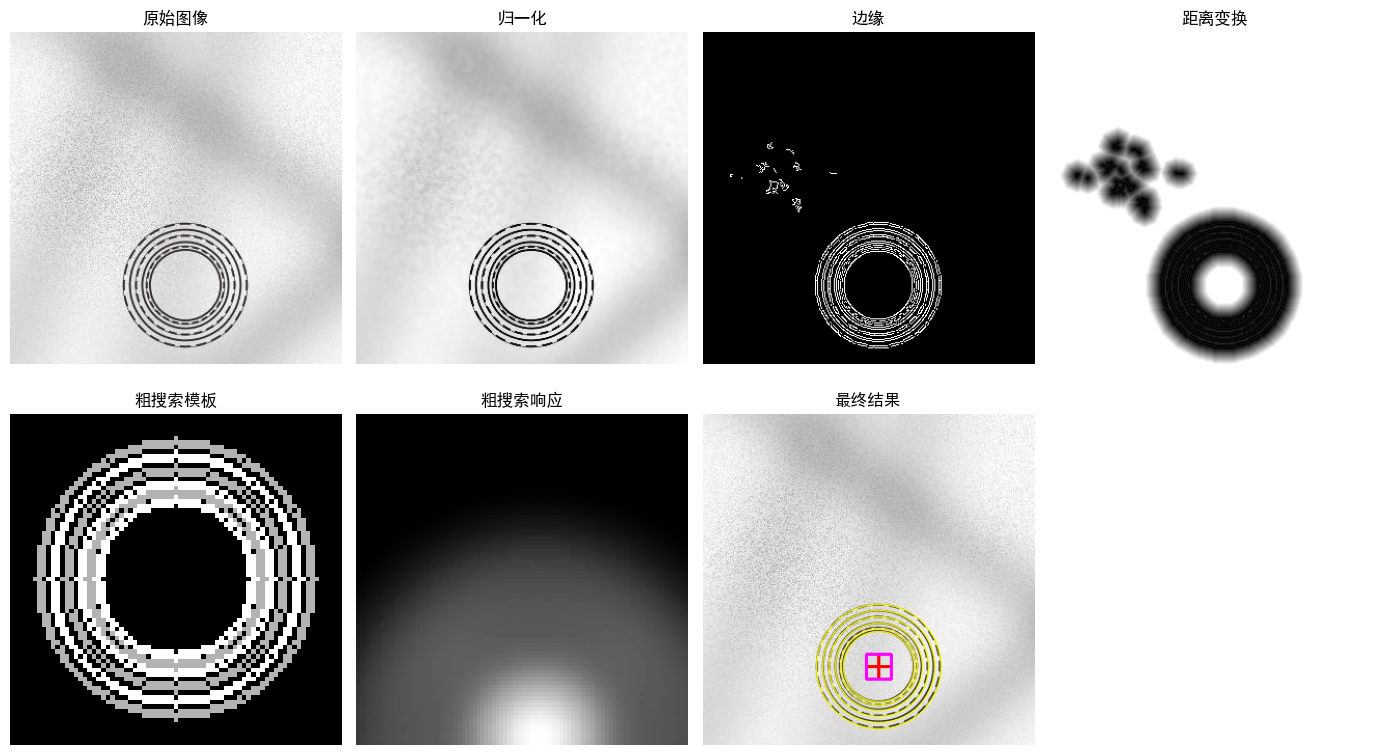

In [ ]:
# 基本推理

import cv2
import re
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 配置
# ============================================================

CFG = {
    "image_path": (
        r"F:\Project\littleCar2\zhengdian\4-29"
        r"\jetson\scripts\圆形检测\v2"
        r"\circle\(169, 244).jpg"
    ),

    # 六个圆环的中心线基础半径
    "base_radii": [27.25, 29.75, 33.25, 37.95, 42.65, 47.35],
    "styles": ["solid", "--", "solid", "--", "solid", "--"],
    "line_width": 1.5,

    # 与生成数据时一致
    "scale_min": 0.60,
    "scale_max": 1.50,

    # 粗搜索
    "coarse_factor": 0.50,
    "coarse_scale_steps": 19,

    # 局部精修
    "refine_window": 10,
    "refine_scale_range": 0.06,
    "refine_scale_steps": 13,

    # 预处理
    "bg_sigma": 25,
    "canny_low": 45,
    "canny_high": 110,
    "distance_cap": 15.0,

    # 模板
    "template_margin": 8,
    "solid_weight": 1.0,
    "dash_weight": 0.7,
}


# ============================================================
# 中文路径读取
# ============================================================

def imread_cn(path):
    path = Path(path)

    if not path.is_file():
        raise FileNotFoundError(f"图像不存在：{path}")

    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"OpenCV 解码失败：{path}")

    return image


def parse_gt(path):
    match = re.search(r"\((\d+),\s*(\d+)\)", Path(path).name)

    if match is None:
        return None

    return int(match.group(1)), int(match.group(2))


# ============================================================
# 图像预处理
# ============================================================

def preprocess(image, factor=1.0):
    if factor != 1.0:
        image = cv2.resize(
            image,
            None,
            fx=factor,
            fy=factor,
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 减少背景亮度不均和条状阴影影响
    sigma = max(1.0, CFG["bg_sigma"] * factor)
    background = cv2.GaussianBlur(gray, (0, 0), sigma)

    normalized = cv2.addWeighted(
        gray,
        1.35,
        background,
        -0.35,
        0
    )

    normalized = cv2.bilateralFilter(
        normalized,
        7,
        45,
        45
    )

    edges = cv2.Canny(
        normalized,
        CFG["canny_low"],
        CFG["canny_high"]
    )

    distance = cv2.distanceTransform(
        255 - edges,
        cv2.DIST_L2,
        3
    )

    distance = np.minimum(
        distance,
        CFG["distance_cap"] * factor
    ).astype(np.float32)

    return normalized, edges, distance


# ============================================================
# 模板生成
# ============================================================

def make_template(scale, factor=1.0):
    radii = np.array(CFG["base_radii"]) * scale * factor
    half_width = CFG["line_width"] * scale * factor / 2

    edge_items = []

    for radius, style in zip(radii, CFG["styles"]):
        weight = (
            CFG["solid_weight"]
            if style == "solid"
            else CFG["dash_weight"]
        )

        edge_items.append((radius - half_width, weight))
        edge_items.append((radius + half_width, weight))

    max_radius = max(radius for radius, _ in edge_items)

    half_size = math.ceil(
        max_radius + CFG["template_margin"] * factor
    )

    size = half_size * 2 + 1
    center = (half_size, half_size)

    template = np.zeros((size, size), dtype=np.float32)

    for radius, weight in edge_items:
        cv2.circle(
            template,
            center,
            int(round(radius)),
            float(weight),
            thickness=1,
            lineType=cv2.LINE_8
        )

    return template, center


# ============================================================
# 低分辨率全局粗搜索
# ============================================================

def coarse_search(distance):
    factor = CFG["coarse_factor"]

    best_score = float("inf")
    best_center = None
    best_scale = None
    best_template = None
    best_response = None

    scales = np.linspace(
        CFG["scale_min"],
        CFG["scale_max"],
        CFG["coarse_scale_steps"]
    )

    for scale in scales:
        template, template_center = make_template(scale, factor)

        if (
            template.shape[0] >= distance.shape[0]
            or template.shape[1] >= distance.shape[1]
        ):
            continue

        weight_sum = template.sum()

        response = cv2.matchTemplate(
            distance,
            template,
            cv2.TM_CCORR
        ) / max(weight_sum, 1e-6)

        min_score, _, min_location, _ = cv2.minMaxLoc(response)

        if min_score < best_score:
            best_score = min_score
            best_scale = scale
            best_template = template
            best_response = response

            center_small = (
                min_location[0] + template_center[0],
                min_location[1] + template_center[1]
            )

            best_center = (
                round(center_small[0] / factor),
                round(center_small[1] / factor)
            )

    if best_center is None:
        raise RuntimeError("粗搜索失败，没有可用模板")

    return (
        best_center,
        best_scale,
        best_score,
        best_template,
        best_response
    )


# ============================================================
# 局部中心评分
# ============================================================

def score_candidate(distance, center, scale):
    template, template_center = make_template(scale)

    ys, xs = np.where(template > 0)
    weights = template[ys, xs]

    xs = center[0] + xs - template_center[0]
    ys = center[1] + ys - template_center[1]

    height, width = distance.shape

    valid = (
        (xs >= 0) &
        (xs < width) &
        (ys >= 0) &
        (ys < height)
    )

    if np.count_nonzero(valid) < 50:
        return float("inf")

    return np.average(
        distance[ys[valid], xs[valid]],
        weights=weights[valid]
    )


# ============================================================
# 原图局部精修
# ============================================================

def refine_search(distance, center0, scale0):
    best_center = center0
    best_scale = scale0
    best_score = score_candidate(distance, center0, scale0)

    scales = np.linspace(
        max(CFG["scale_min"], scale0 - CFG["refine_scale_range"]),
        min(CFG["scale_max"], scale0 + CFG["refine_scale_range"]),
        CFG["refine_scale_steps"]
    )

    window = CFG["refine_window"]

    for scale in scales:
        for dy in range(-window, window + 1):
            for dx in range(-window, window + 1):
                center = (
                    center0[0] + dx,
                    center0[1] + dy
                )

                score = score_candidate(
                    distance,
                    center,
                    scale
                )

                if score < best_score:
                    best_score = score
                    best_center = center
                    best_scale = scale

    return best_center, best_scale, best_score


# ============================================================
# 结果绘制
# ============================================================

def draw_result(image, center, scale, gt=None):
    output = image.copy()

    # 检测中心
    cv2.drawMarker(
        output,
        center,
        (0, 0, 255),
        cv2.MARKER_CROSS,
        25,
        2
    )

    # 模板中心线
    for radius in CFG["base_radii"]:
        cv2.circle(
            output,
            center,
            round(radius * scale),
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

    # 文件名中的真实中心
    if gt is not None:
        cv2.drawMarker(
            output,
            gt,
            (255, 0, 255),
            cv2.MARKER_SQUARE,
            25,
            2
        )

    return output


# ============================================================
# 主函数
# ============================================================

def main():
    image_path = CFG["image_path"]

    image = imread_cn(image_path)
    gt = parse_gt(image_path)

    normalized, edges, distance = preprocess(image)

    _, _, distance_small = preprocess(
        image,
        CFG["coarse_factor"]
    )

    center0, scale0, coarse_score, template, response = (
        coarse_search(distance_small)
    )

    center, scale, final_score = refine_search(
        distance,
        center0,
        scale0
    )

    error = None

    if gt is not None:
        error = math.hypot(
            center[0] - gt[0],
            center[1] - gt[1]
        )

    print("图像：", Path(image_path).name)
    print("粗搜索中心：", center0)
    print("最终中心：", center)
    print("真实中心：", gt)
    print("缩放倍率：", round(scale, 4))
    print("匹配分数：", round(float(final_score), 4))

    if error is not None:
        print("中心误差：", round(error, 3), "px")

    result_image = draw_result(
        image,
        center,
        scale,
        gt
    )

    distance_vis = cv2.normalize(
        distance,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    response_vis = cv2.normalize(
        response,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    plt.figure(figsize=(14, 8))

    images = [
        (image, "原始图像"),
        (normalized, "归一化"),
        (edges, "边缘"),
        (distance_vis, "距离变换"),
        (template, "粗搜索模板"),
        (255 - response_vis, "粗搜索响应"),
        (result_image, "最终结果")
    ]

    for index, (plot_image, title) in enumerate(images):
        plt.subplot(2, 4, index + 1)

        if plot_image.ndim == 2:
            plt.imshow(plot_image, cmap="gray")
        else:
            plt.imshow(
                cv2.cvtColor(
                    plot_image,
                    cv2.COLOR_BGR2RGB
                )
            )

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
# 批量测试

1. (216, 108).jpg | 预测=(216, 109) | 真实=(216, 108) | scale=1.500 | 误差=1.00px | 延时=7450.76ms
2. (205, 136).jpg | 预测=(204, 135) | 真实=(205, 136) | scale=1.280 | 误差=1.41px | 延时=7216.82ms
3. (211, 173).jpg | 预测=(210, 173) | 真实=(211, 173) | scale=0.637 | 误差=1.00px | 延时=7283.94ms
4. (244, 225).jpg | 预测=(244, 224) | 真实=(244, 225) | scale=0.698 | 误差=1.00px | 延时=7169.79ms
5. (164, 116).jpg | 预测=(112, 167) | 真实=(164, 116) | scale=0.610 | 误差=72.84px | 延时=6729.06ms
6. (187, 136).jpg | 预测=(186, 136) | 真实=(187, 136) | scale=0.940 | 误差=1.00px | 延时=7262.66ms
7. (110, 188).jpg | 预测=(109, 187) | 真实=(110, 188) | scale=1.485 | 误差=1.41px | 延时=7650.83ms
8. (84, 251).jpg | 预测=(83, 251) | 真实=(84, 251) | scale=0.840 | 误差=1.00px | 延时=7226.70ms
9. (182, 115).jpg | 预测=(232, 165) | 真实=(182, 115) | scale=0.610 | 误差=70.71px | 延时=6867.82ms


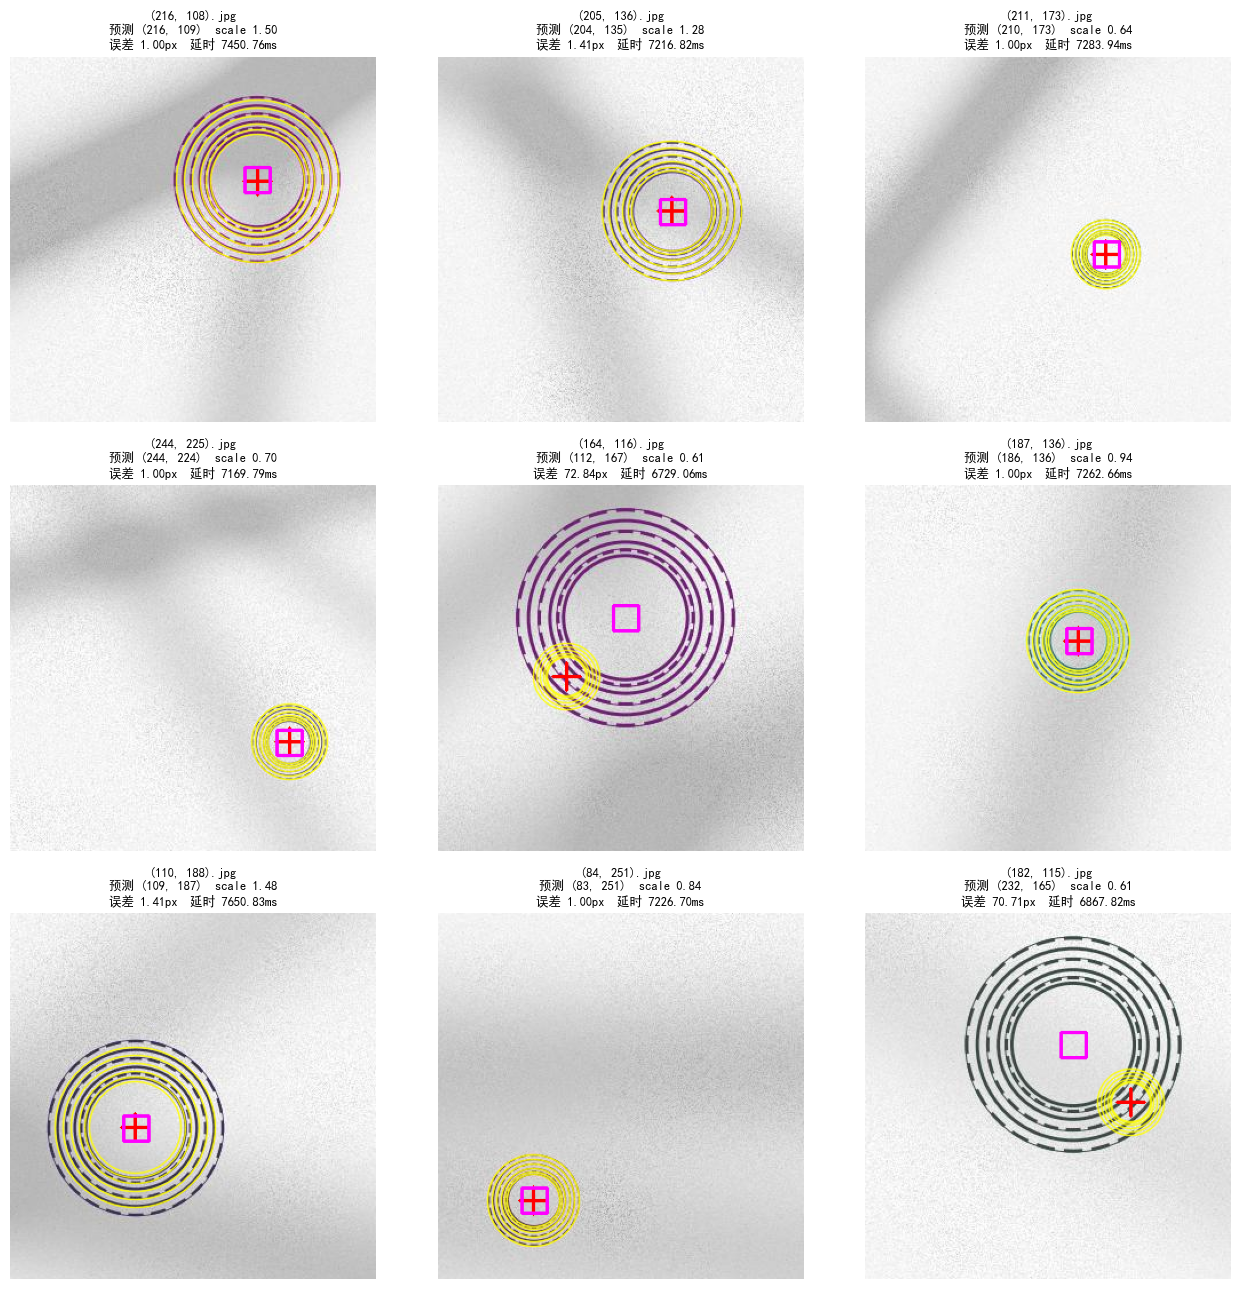

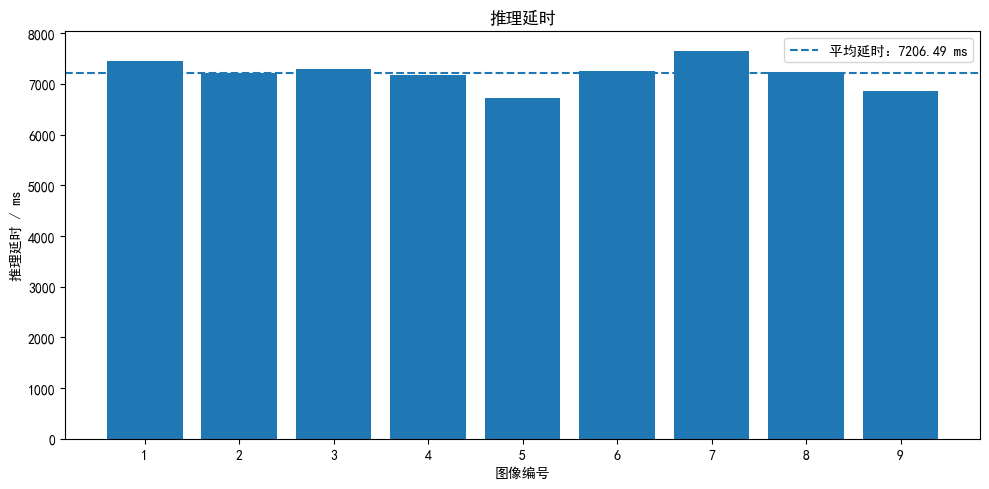

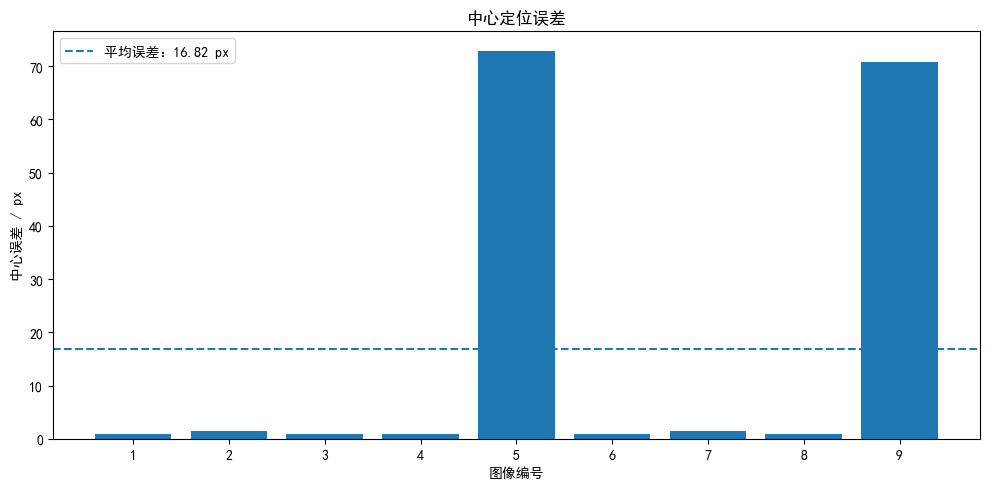

In [5]:
import cv2
import re
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 统一配置区
# ============================================================

IMAGE_DIR = Path(
    r"F:\Project\littleCar2\zhengdian\4-29"
    r"\jetson\scripts\圆形检测\v2\circle"
)

IMAGE_COUNT = 9
RANDOM_SEED = None

# 图案结构
BASE_RADII = np.array(
    [27.25, 29.75, 33.25, 37.95, 42.65, 47.35],
    dtype=np.float32
)

RING_STYLES = ["solid", "dash", "solid", "dash", "solid", "dash"]
LINE_WIDTH = 1.5

SOLID_WEIGHT = 1.0
DASH_WEIGHT = 0.35

# 尺度搜索
SCALE_MIN = 0.60
SCALE_MAX = 1.50

# 大图案识别的关键参数
COARSE_FACTOR = 0.75
COARSE_SCALE_STEPS = 37
COARSE_CANDIDATE_COUNT = 8
REFINE_CANDIDATE_COUNT = 2

# 局部精修
REFINE_WINDOW = 14
REFINE_STEP = 1
REFINE_SCALE_RANGE = 0.10
REFINE_SCALE_STEPS = 21

# 图像预处理
BG_SIGMA = 25
NORMALIZE_ALPHA = 1.35
NORMALIZE_BETA = -0.35

BILATERAL_D = 7
BILATERAL_SIGMA_COLOR = 45
BILATERAL_SIGMA_SPACE = 45

CANNY_LOW = 40
CANNY_HIGH = 100

DISTANCE_CAP = 15.0

# 模板
TEMPLATE_MARGIN = 8
MIN_VALID_TEMPLATE_POINTS = 50

# 圆周覆盖率验证
RADIAL_SAMPLE_COUNT = 96
RADIAL_TOLERANCE = 2.5

# 虚线圈本身存在间断，因此阈值低于实线圈
SOLID_EXPECTED_COVERAGE = 0.65
DASH_EXPECTED_COVERAGE = 0.35

# 综合评分：越小越好
RADIAL_SCORE_WEIGHT = 4.0

# 绘图
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 基础工具
# ============================================================

def imread_cn(path):
    data = np.fromfile(str(path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"无法读取图像：{path}")

    return image


def parse_gt(path):
    match = re.search(r"\((\d+),\s*(\d+)\)", path.name)

    if match is None:
        return None

    return int(match.group(1)), int(match.group(2))


# ============================================================
# 图像预处理
# ============================================================

def preprocess(image, factor=1.0):
    if factor != 1.0:
        image = cv2.resize(
            image,
            None,
            fx=factor,
            fy=factor,
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    background = cv2.GaussianBlur(
        gray,
        (0, 0),
        max(1.0, BG_SIGMA * factor)
    )

    normalized = cv2.addWeighted(
        gray,
        NORMALIZE_ALPHA,
        background,
        NORMALIZE_BETA,
        0
    )

    normalized = cv2.bilateralFilter(
        normalized,
        BILATERAL_D,
        BILATERAL_SIGMA_COLOR,
        BILATERAL_SIGMA_SPACE
    )

    edges = cv2.Canny(
        normalized,
        CANNY_LOW,
        CANNY_HIGH
    )

    distance = cv2.distanceTransform(
        255 - edges,
        cv2.DIST_L2,
        3
    )

    distance = np.minimum(
        distance,
        DISTANCE_CAP * factor
    ).astype(np.float32)

    return edges, distance


# ============================================================
# 模板生成
# ============================================================

template_cache = {}


def make_template(scale, factor=1.0):
    key = (round(float(scale), 5), round(float(factor), 3))

    if key in template_cache:
        return template_cache[key]

    radii = BASE_RADII * scale * factor
    half_width = LINE_WIDTH * scale * factor / 2

    edge_items = []

    for radius, style in zip(radii, RING_STYLES):
        weight = SOLID_WEIGHT if style == "solid" else DASH_WEIGHT

        edge_items.append((radius - half_width, weight))
        edge_items.append((radius + half_width, weight))

    max_radius = max(radius for radius, _ in edge_items)
    half_size = math.ceil(max_radius + TEMPLATE_MARGIN * factor)

    template = np.zeros(
        (half_size * 2 + 1, half_size * 2 + 1),
        dtype=np.float32
    )

    center = (half_size, half_size)

    for radius, weight in edge_items:
        cv2.circle(
            template,
            center,
            int(round(radius)),
            float(weight),
            1,
            cv2.LINE_8
        )

    ys, xs = np.where(template > 0)

    result = {
        "image": template,
        "center": center,
        "offsets": np.column_stack(
            (xs - center[0], ys - center[1])
        ),
        "weights": template[ys, xs]
    }

    template_cache[key] = result
    return result


# ============================================================
# 候选评分
# ============================================================

def chamfer_score(distance, center, scale):
    template = make_template(scale)

    offsets = template["offsets"]
    weights = template["weights"]

    xs = center[0] + offsets[:, 0]
    ys = center[1] + offsets[:, 1]

    height, width = distance.shape

    valid = (
        (xs >= 0) & (xs < width) &
        (ys >= 0) & (ys < height)
    )

    if np.count_nonzero(valid) < MIN_VALID_TEMPLATE_POINTS:
        return float("inf")

    return float(np.average(
        distance[ys[valid], xs[valid]],
        weights=weights[valid]
    ))


def radial_coverage(distance, center, scale):
    """
    检查六个预期圆周上是否广泛存在边缘。

    真中心：各方向均能采样到圆环。
    假中心：通常只在某一局部方向存在弧线。
    """
    angles = np.linspace(
        0,
        2 * np.pi,
        RADIAL_SAMPLE_COUNT,
        endpoint=False
    )

    cos_values = np.cos(angles)
    sin_values = np.sin(angles)

    height, width = distance.shape
    scores = []

    for radius, style in zip(BASE_RADII * scale, RING_STYLES):
        xs = np.rint(center[0] + radius * cos_values).astype(np.int32)
        ys = np.rint(center[1] + radius * sin_values).astype(np.int32)

        valid = (
            (xs >= 0) & (xs < width) &
            (ys >= 0) & (ys < height)
        )

        if np.count_nonzero(valid) == 0:
            scores.append(0.0)
            continue

        coverage = np.mean(
            distance[ys[valid], xs[valid]] <= RADIAL_TOLERANCE
        )

        expected = (
            SOLID_EXPECTED_COVERAGE
            if style == "solid"
            else DASH_EXPECTED_COVERAGE
        )

        scores.append(min(coverage / expected, 1.0))

    return float(np.mean(scores))


def combined_score(distance, center, scale):
    chamfer = chamfer_score(distance, center, scale)
    coverage = radial_coverage(distance, center, scale)

    return chamfer - RADIAL_SCORE_WEIGHT * coverage


# ============================================================
# 搜索算法
# ============================================================

def coarse_search(distance_small, distance_full):
    candidates = []

    scales = np.linspace(
        SCALE_MIN,
        SCALE_MAX,
        COARSE_SCALE_STEPS
    )

    for scale in scales:
        template_data = make_template(scale, COARSE_FACTOR)
        template = template_data["image"]

        if (
            template.shape[0] >= distance_small.shape[0]
            or template.shape[1] >= distance_small.shape[1]
        ):
            continue

        response = cv2.matchTemplate(
            distance_small,
            template,
            cv2.TM_CCORR
        )

        response /= max(template.sum(), 1e-6)

        score, _, location, _ = cv2.minMaxLoc(response)

        center_small = (
            location[0] + template_data["center"][0],
            location[1] + template_data["center"][1]
        )

        center_full = (
            round(center_small[0] / COARSE_FACTOR),
            round(center_small[1] / COARSE_FACTOR)
        )

        candidates.append((score, center_full, float(scale)))

    candidates.sort(key=lambda item: item[0])
    candidates = candidates[:COARSE_CANDIDATE_COUNT]

    rescored = []

    for _, center, scale in candidates:
        score = combined_score(
            distance_full,
            center,
            scale
        )

        rescored.append((score, center, scale))

    rescored.sort(key=lambda item: item[0])

    return rescored[:REFINE_CANDIDATE_COUNT]


def refine_search(distance, center0, scale0):
    best_center = center0
    best_scale = scale0
    best_score = combined_score(distance, center0, scale0)

    scales = np.linspace(
        max(SCALE_MIN, scale0 - REFINE_SCALE_RANGE),
        min(SCALE_MAX, scale0 + REFINE_SCALE_RANGE),
        REFINE_SCALE_STEPS
    )

    for scale in scales:
        for dy in range(
            -REFINE_WINDOW,
            REFINE_WINDOW + 1,
            REFINE_STEP
        ):
            for dx in range(
                -REFINE_WINDOW,
                REFINE_WINDOW + 1,
                REFINE_STEP
            ):
                center = (
                    center0[0] + dx,
                    center0[1] + dy
                )

                score = combined_score(
                    distance,
                    center,
                    scale
                )

                if score < best_score:
                    best_score = score
                    best_center = center
                    best_scale = float(scale)

    return best_center, best_scale, best_score


# ============================================================
# 完整推理函数
# ============================================================

def infer(image):
    """
    计时范围：
    预处理 + 粗搜索 + 局部精修。

    不包含图像读取和结果绘制。
    """
    start_time = time.perf_counter()

    _, distance_full = preprocess(image)
    _, distance_small = preprocess(image, COARSE_FACTOR)

    coarse_candidates = coarse_search(
        distance_small,
        distance_full
    )

    best_result = None

    for _, center0, scale0 in coarse_candidates:
        center, scale, score = refine_search(
            distance_full,
            center0,
            scale0
        )

        if best_result is None or score < best_result[2]:
            best_result = (center, scale, score)

    latency_ms = (
        time.perf_counter() - start_time
    ) * 1000

    center, scale, score = best_result

    return center, scale, score, latency_ms


# ============================================================
# 结果绘制
# ============================================================

def draw_result(image, center, scale, gt):
    output = image.copy()

    for radius in BASE_RADII:
        cv2.circle(
            output,
            center,
            round(float(radius * scale)),
            (0, 255, 255),
            1,
            cv2.LINE_AA
        )

    cv2.drawMarker(
        output,
        center,
        (0, 0, 255),
        cv2.MARKER_CROSS,
        25,
        2
    )

    cv2.drawMarker(
        output,
        gt,
        (255, 0, 255),
        cv2.MARKER_SQUARE,
        22,
        2
    )

    return output


# ============================================================
# 主函数
# ============================================================

def main():
    image_paths = []

    for pattern in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
        image_paths.extend(IMAGE_DIR.glob(pattern))

    image_paths = [
        path for path in image_paths
        if parse_gt(path) is not None
    ]

    if len(image_paths) < IMAGE_COUNT:
        raise RuntimeError(
            f"有效图像不足 {IMAGE_COUNT} 张，当前为 {len(image_paths)} 张"
        )

    selected_paths = random.Random(RANDOM_SEED).sample(
        image_paths,
        IMAGE_COUNT
    )

    results = []

    for index, path in enumerate(selected_paths, start=1):
        image = imread_cn(path)
        gt = parse_gt(path)

        center, scale, score, latency = infer(image)

        error = math.hypot(
            center[0] - gt[0],
            center[1] - gt[1]
        )

        results.append({
            "index": index,
            "path": path,
            "image": draw_result(image, center, scale, gt),
            "center": center,
            "gt": gt,
            "scale": scale,
            "score": score,
            "latency": latency,
            "error": error
        })

        print(
            f"{index}. {path.name} | "
            f"预测={center} | "
            f"真实={gt} | "
            f"scale={scale:.3f} | "
            f"误差={error:.2f}px | "
            f"延时={latency:.2f}ms"
        )

    # 3×3 推理结果
    plt.figure(figsize=(13, 13))

    for result in results:
        plt.subplot(3, 3, result["index"])

        plt.imshow(
            cv2.cvtColor(
                result["image"],
                cv2.COLOR_BGR2RGB
            )
        )

        plt.title(
            f"{result['path'].name}\n"
            f"预测 {result['center']}  "
            f"scale {result['scale']:.2f}\n"
            f"误差 {result['error']:.2f}px  "
            f"延时 {result['latency']:.2f}ms",
            fontsize=9
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    labels = [str(result["index"]) for result in results]
    latencies = [result["latency"] for result in results]
    errors = [result["error"] for result in results]

    # 延时柱状图
    plt.figure(figsize=(10, 5))
    plt.bar(labels, latencies)
    plt.axhline(
        np.mean(latencies),
        linestyle="--",
        label=f"平均延时：{np.mean(latencies):.2f} ms"
    )
    plt.xlabel("图像编号")
    plt.ylabel("推理延时 / ms")
    plt.title("推理延时")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 误差柱状图
    plt.figure(figsize=(10, 5))
    plt.bar(labels, errors)
    plt.axhline(
        np.mean(errors),
        linestyle="--",
        label=f"平均误差：{np.mean(errors):.2f} px"
    )
    plt.xlabel("图像编号")
    plt.ylabel("中心误差 / px")
    plt.title("中心定位误差")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

# 高速方法

已随机选择测试图像: (216, 108).jpg
真值中心点 (Ground Truth): X=216.00, Y=108.00

--- 第一次推理 (包含图像显示准备) ---
步骤1：读取与灰度化耗时: 1.23 ms
步骤2：自适应阈值耗时    : 0.86 ms
步骤3：轮廓提取与粗定位  : 2.40 ms
步骤4：RANSAC亚像素精拟合: 9.33 ms
【含IO与计算总耗时】    : 13.82 ms
检测出的亚像素中心: X=215.5063, Y=107.5380
中心定位欧氏误差: 0.6761 像素

--- 第二次纯推理 (无绘制，测试纯算法时延) ---
步骤1：读取与灰度化耗时: 0.80 ms
步骤2：自适应阈值耗时    : 0.91 ms
步骤3：轮廓提取与粗定位  : 2.55 ms
步骤4：RANSAC亚像素精拟合: 6.57 ms
【纯算法流程总时延】    : 10.84 ms

正在生成可视化图表，请查看...


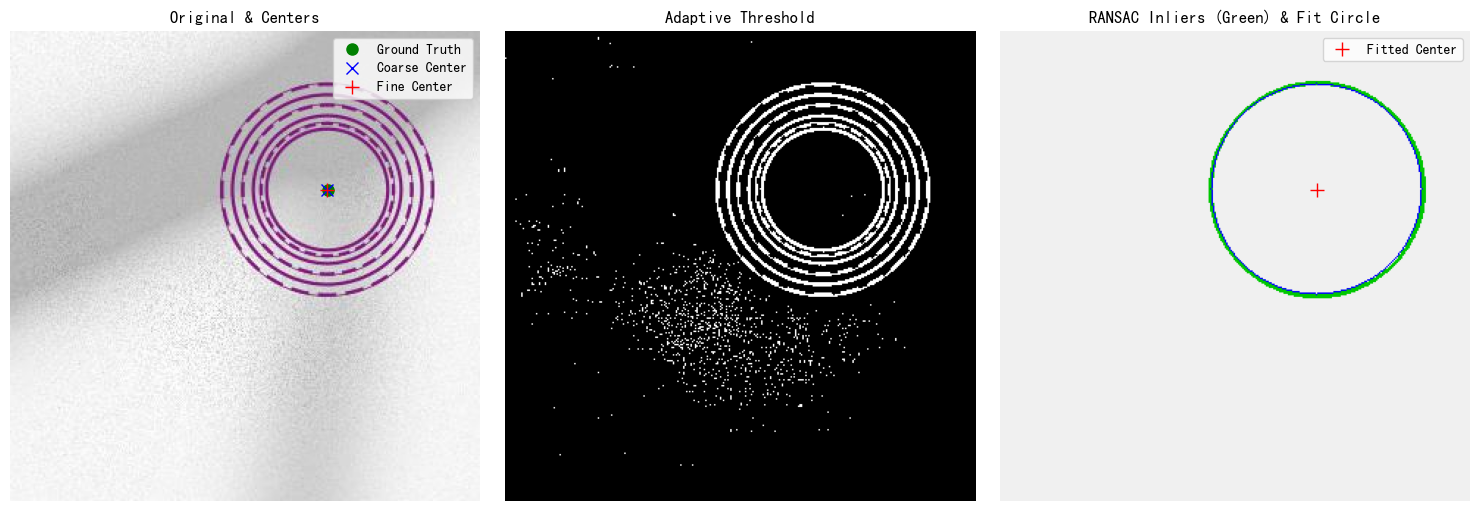

In [27]:
import os
import re
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ==========================================
# 1. 路径与参数配置
# ==========================================
IMAGE_DIR = r"F:\Project\littleCar2\zhengdian\4-29\jetson\scripts\圆形检测\v2\circle"

# 检查路径，如果不存在则使用当前工作目录下的circle文件夹
if not os.path.exists(IMAGE_DIR):
    IMAGE_DIR = os.path.join(os.getcwd(), "circle")
    print(f"提示：未找到指定绝对路径，切换至当前目录：{IMAGE_DIR}")

# ==========================================
# 2. 核心数学拟合算法
# ==========================================
def algebraic_circle_fit(pts):
    """
    使用 Kåsa 线性最小二乘法拟合圆
    输入: pts (N, 2)
    输出: (cx, cy, R)
    """
    x = pts[:, 0]
    y = pts[:, 1]
    # 建立线性方程组 A * p = B
    A = np.column_stack((2 * x, 2 * y, np.ones(len(x))))
    B = x**2 + y**2
    try:
        p, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
        cx, cy = p[0], p[1]
        R = np.sqrt(p[2] + cx**2 + cy**2)
        return cx, cy, R
    except (np.linalg.LinAlgError, ValueError):
        return None

def ransac_circle_fit(pts, n_iter=120, threshold=1.2):
    """
    使用 RANSAC 算法拟合圆，用于排除齿部（Outliers）干扰
    """
    if len(pts) < 3:
        return None, []
    
    best_inliers = []
    best_model = None
    
    for _ in range(n_iter):
        # 随机抽取3个点确定一个圆
        sample_idx = np.random.choice(len(pts), 3, replace=False)
        sample = pts[sample_idx]
        
        model = algebraic_circle_fit(sample)
        if model is None:
            continue
        cx, cy, R = model
        if np.isnan(cx) or np.isnan(cy) or np.isnan(R) or R <= 0:
            continue
            
        # 计算所有点到该圆的距离误差
        dists = np.abs(np.linalg.norm(pts - np.array([cx, cy]), axis=1) - R)
        inliers = np.where(dists < threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = model
            
    if len(best_inliers) >= 3:
        # 使用所有的局内点重新进行高精度拟合
        final_model = algebraic_circle_fit(pts[best_inliers])
        return final_model, best_inliers
    
    return best_model, best_inliers

# ==========================================
# 3. 图像检测完整流水线
# ==========================================
def parse_gt_center(filename):
    """从文件名解析真实中心点坐标，如 '(84, 225).jpg'"""
    match = re.search(r"\((\d+),\s*(\d+)\)", filename)
    if match:
        return float(match.group(1)), float(match.group(2))
    return None

def detect_circle_center(img_path, visualize=False):
    """
    单张图像的检测流水线
    """
    metrics = {}
    steps_data = {}
    
    t_start = time.perf_counter()
    
    # --- 步骤 1：读取与预处理 ---
    t0 = time.perf_counter()
    
    # 使用 np.fromfile 绕过 OpenCV 无法解析中文路径的问题
    try:
        img_array = np.fromfile(img_path, dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    except Exception as e:
        raise FileNotFoundError(f"读取文件时发生系统错误: {e}")
        
    if img is None:
        raise FileNotFoundError(f"无法解析图像（可能文件已损坏或路径错误）: {img_path}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    t_preprocess = time.perf_counter() - t0
    
    # --- 步骤 2：自适应阈值二值化（抗噪与抗影子） ---
    t0 = time.perf_counter()
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 51, 15
    )
    t_thresh = time.perf_counter() - t0
    
    # --- 步骤 3：粗定位（查找同心轮廓） ---
    t0 = time.perf_counter()
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    
    valid_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 120:  # 过滤斑点噪声
            continue
        x_b, y_b, w_b, h_b = cv2.boundingRect(cnt)
        aspect_ratio = float(w_b) / h_b
        if 0.75 < aspect_ratio < 1.25:
            valid_contours.append(cnt)
            
    if not valid_contours:
        return None, "未找到有效的圆环轮廓"
        
    # 选择面积最大的轮廓（即最外层齿轮环的外边界）
    outermost_contour = max(valid_contours, key=cv2.contourArea)
    
    # 粗定位中心
    M = cv2.moments(outermost_contour)
    if M["m00"] == 0:
        return None, "轮廓面积为0"
    cx_coarse = M["m10"] / M["m00"]
    cy_coarse = M["m01"] / M["m00"]
    t_coarse = time.perf_counter() - t0
    
    # --- 步骤 4：精定位（RANSAC亚像素拟合） ---
    t0 = time.perf_counter()
    pts = outermost_contour.squeeze(axis=1).astype(np.float32)
    
    # 齿轮齿高与噪点等作为局外点过滤（阈值设为1.2像素左右）
    fit_res, inliers = ransac_circle_fit(pts, n_iter=100, threshold=1.2)
    if fit_res is None:
        return None, "RANSAC 拟合失败"
    
    cx_fine, cy_fine, R_fine = fit_res
    t_fine = time.perf_counter() - t0
    
    t_total = time.perf_counter() - t_start
    
    # 保存时间统计与检测结果
    metrics = {
        "t_preprocess_ms": t_preprocess * 1000,
        "t_thresh_ms": t_thresh * 1000,
        "t_coarse_ms": t_coarse * 1000,
        "t_fine_ms": t_fine * 1000,
        "t_total_ms": t_total * 1000,
        "coarse_center": (cx_coarse, cy_coarse),
        "fine_center": (cx_fine, cy_fine),
        "radius": R_fine
    }
    
    if visualize:
        steps_data = {
            "img_bgr": img,
            "thresh": thresh,
            "contour_pts": pts,
            "inlier_pts": pts[inliers] if len(inliers) > 0 else np.array([])
        }
        
    return metrics, steps_data

# ==========================================
# 4. 主执行逻辑
# ==========================================
def main():
    if not os.path.exists(IMAGE_DIR):
        print(f"错误：文件夹不存在 {IMAGE_DIR}，请确认路径。")
        return
        
    # 获取所有图像文件
    img_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.png'))]
    if not img_files:
        print(f"错误：在 {IMAGE_DIR} 中未找到图像文件。")
        return
        
    # 1. 随机选取一张图像
    test_file = random.choice(img_files)
    img_path = os.path.join(IMAGE_DIR, test_file)
    gt_center = parse_gt_center(test_file)
    
    print(f"已随机选择测试图像: {test_file}")
    if gt_center:
        print(f"真值中心点 (Ground Truth): X={gt_center[0]:.2f}, Y={gt_center[1]:.2f}")
    
    # 2. 第一次推理（带图像绘制，统计各步骤耗时）
    print("\n--- 第一次推理 (包含图像显示准备) ---")
    metrics, steps = detect_circle_center(img_path, visualize=True)
    
    if metrics is None:
        print(f"检测失败: {steps}")
        return
        
    print(f"步骤1：读取与灰度化耗时: {metrics['t_preprocess_ms']:.2f} ms")
    print(f"步骤2：自适应阈值耗时    : {metrics['t_thresh_ms']:.2f} ms")
    print(f"步骤3：轮廓提取与粗定位  : {metrics['t_coarse_ms']:.2f} ms")
    print(f"步骤4：RANSAC亚像素精拟合: {metrics['t_fine_ms']:.2f} ms")
    print(f"【含IO与计算总耗时】    : {metrics['t_total_ms']:.2f} ms")
    
    cx_f, cy_f = metrics['fine_center']
    print(f"检测出的亚像素中心: X={cx_f:.4f}, Y={cy_f:.4f}")
    if gt_center:
        err = np.sqrt((cx_f - gt_center[0])**2 + (cy_f - gt_center[1])**2)
        print(f"中心定位欧氏误差: {err:.4f} 像素")
        
    # 3. 重新推理一次（纯计算，排除所有可视化/绘图干扰，测试真实延时）
    print("\n--- 第二次纯推理 (无绘制，测试纯算法时延) ---")
    pure_metrics, _ = detect_circle_center(img_path, visualize=False)
    print(f"步骤1：读取与灰度化耗时: {pure_metrics['t_preprocess_ms']:.2f} ms")
    print(f"步骤2：自适应阈值耗时    : {pure_metrics['t_thresh_ms']:.2f} ms")
    print(f"步骤3：轮廓提取与粗定位  : {pure_metrics['t_coarse_ms']:.2f} ms")
    print(f"步骤4：RANSAC亚像素精拟合: {pure_metrics['t_fine_ms']:.2f} ms")
    print(f"【纯算法流程总时延】    : {pure_metrics['t_total_ms']:.2f} ms")

    # 4. 可视化绘制每一步的图像
    print("\n正在生成可视化图表，请查看...")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 图1：原图 + 粗/精定位中心对比
    img_bgr = steps["img_bgr"].copy()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_rgb)
    if gt_center:
        axes[0].plot(gt_center[0], gt_center[1], 'go', markersize=8, label='Ground Truth')
    cx_c, cy_c = metrics['coarse_center']
    axes[0].plot(cx_c, cy_c, 'bx', markersize=8, label='Coarse Center')
    axes[0].plot(cx_f, cy_f, 'r+', markersize=10, label='Fine Center')
    axes[0].set_title("Original & Centers")
    axes[0].legend()
    axes[0].axis('off')
    
    # 图2：自适应二值化结果（展示阴影被消除后的效果）
    axes[1].imshow(steps["thresh"], cmap='gray')
    axes[1].set_title("Adaptive Threshold")
    axes[1].axis('off')
    
    # 图3：轮廓点、RANSAC局内点及最终拟合圆弧
    h, w = steps["thresh"].shape
    contour_img = np.zeros((h, w, 3), dtype=np.uint8) + 240
    for pt in steps["contour_pts"]:
        cv2.circle(contour_img, (int(pt[0]), int(pt[1])), 1, (180, 180, 180), -1)
    for pt in steps["inlier_pts"]:
        cv2.circle(contour_img, (int(pt[0]), int(pt[1])), 1, (0, 200, 0), -1)
    cv2.circle(contour_img, (int(cx_f), int(cy_f)), int(metrics['radius']), (0, 0, 255), 1)
    
    axes[2].imshow(contour_img)
    axes[2].plot(cx_f, cy_f, 'r+', markersize=10, label='Fitted Center')
    axes[2].set_title("RANSAC Inliers (Green) & Fit Circle")
    axes[2].legend()
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

测试图像：(115, 98).jpg
真实中心：(115.0, 98.0)
预测中心：(114.479, 97.495)
拟合半径：74.059 px
缩放倍率：1.5397
结构评分：1.000
匹配圆环：6/6
各圆覆盖率： [1.0, 0.75, 1.0, 0.75, 1.0, 0.99]
中心误差：0.7259 px

单次各阶段耗时
预处理：1.177 ms
轮廓筛选：1.493 ms
圆拟合：3.861 ms
结构验证：0.393 ms
总延时：6.927 ms

纯算法性能统计
平均延时：4.174 ms
中位延时：4.099 ms
P95 延时：4.763 ms
最大延时：4.912 ms


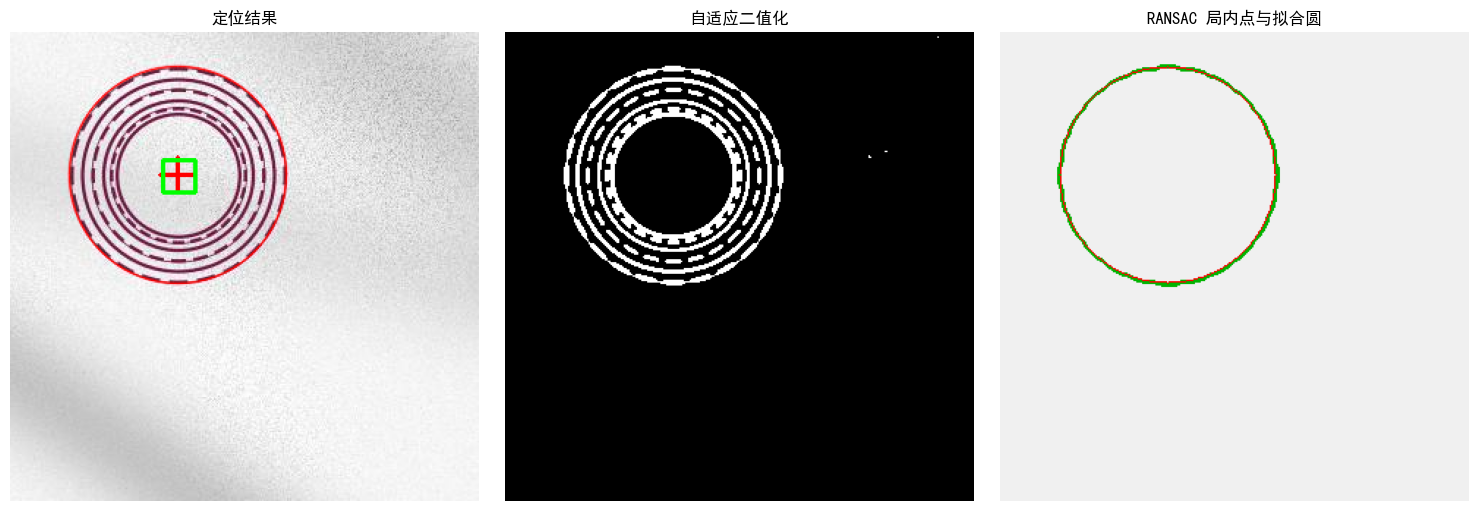

In [34]:
import os
import re
import math
import time
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 参数配置
# ============================================================

IMAGE_DIR = (
    r"F:\Project\littleCar2\zhengdian\4-29"
    r"\jetson\scripts\圆形检测\v2\circle"
)

RANDOM_SEED = None

# 预处理
BLUR_KERNEL = (5, 5)
BLUR_SIGMA = 1.0

ADAPTIVE_BLOCK_SIZE = 51
ADAPTIVE_C = 15

# 轮廓筛选
MIN_CONTOUR_AREA = 1200
MIN_ASPECT_RATIO = 0.80
MAX_ASPECT_RATIO = 1.20
MIN_CIRCULARITY = 0.50
BORDER_MARGIN = 3

# 最外层圆半径范围
MIN_OUTER_RADIUS = 26.0
MAX_OUTER_RADIUS = 76.0

# RANSAC
RANSAC_ITERATIONS = 80
RANSAC_THRESHOLD = 1.5
RANSAC_MAX_POINTS = 300
MIN_INLIER_RATIO = 0.40
COLLINEAR_EPS = 1e-4

# 几何精修
GEOMETRIC_REFINE_ITERATIONS = 5
GEOMETRIC_STOP_EPS = 1e-4

# 六圈结构
BASE_CENTER_RADII = np.array(
    [27.25, 29.75, 33.25, 37.95, 42.65, 47.35],
    dtype=np.float32
)

RING_TYPES = [
    "solid",
    "dash",
    "solid",
    "dash",
    "solid",
    "dash"
]

BASE_OUTER_RADIUS = 48.10
BASE_LINE_WIDTH = 1.50

RADIAL_SAMPLE_COUNT = 96
RADIAL_SAMPLE_BAND = 1

SOLID_MIN_COVERAGE = 0.50
DASH_MIN_COVERAGE = 0.25

MIN_MATCHED_RINGS = 4
MIN_PATTERN_SCORE = 0.70

# 性能测试
WARMUP_RUNS = 5
BENCHMARK_RUNS = 30

plt.rcParams["font.sans-serif"] = [
    "SimHei",
    "Microsoft YaHei",
    "sans-serif"
]
plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 2. 基础工具
# ============================================================

def read_image(path):
    """读取包含中文字符的图像路径。"""
    data = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)

    if image is None:
        raise FileNotFoundError(f"无法读取图像：{path}")

    return image


def parse_gt_center(filename):
    """从 '(169, 244).jpg' 中解析真实中心点。"""
    match = re.search(r"\((\d+),\s*(\d+)\)", filename)

    if match is None:
        return None

    return float(match.group(1)), float(match.group(2))


# ============================================================
# 3. 圆拟合
# ============================================================

def circle_from_three_points(p1, p2, p3):
    """通过三个非共线点计算唯一外接圆。"""
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3

    denominator = 2.0 * (
        x1 * (y2 - y3)
        + x2 * (y3 - y1)
        + x3 * (y1 - y2)
    )

    if abs(denominator) < COLLINEAR_EPS:
        return None

    q1 = x1 * x1 + y1 * y1
    q2 = x2 * x2 + y2 * y2
    q3 = x3 * x3 + y3 * y3

    cx = (
        q1 * (y2 - y3)
        + q2 * (y3 - y1)
        + q3 * (y1 - y2)
    ) / denominator

    cy = (
        q1 * (x3 - x2)
        + q2 * (x1 - x3)
        + q3 * (x2 - x1)
    ) / denominator

    radius = math.hypot(x1 - cx, y1 - cy)

    if not np.isfinite([cx, cy, radius]).all():
        return None

    return float(cx), float(cy), float(radius)


def algebraic_circle_fit(points):
    """Kåsa 线性圆拟合，用于局内点初始拟合。"""
    if len(points) < 3:
        return None

    x = points[:, 0]
    y = points[:, 1]

    matrix = np.column_stack((
        2.0 * x,
        2.0 * y,
        np.ones(len(points))
    ))

    target = x * x + y * y

    try:
        params, _, _, _ = np.linalg.lstsq(
            matrix,
            target,
            rcond=None
        )
    except np.linalg.LinAlgError:
        return None

    cx, cy, constant = params
    radius_square = constant + cx * cx + cy * cy

    if radius_square <= 0:
        return None

    return float(cx), float(cy), float(np.sqrt(radius_square))


def geometric_circle_refine(points, model):
    """最小化点到圆的几何距离。"""
    cx, cy, radius = model

    for _ in range(GEOMETRIC_REFINE_ITERATIONS):
        dx = points[:, 0] - cx
        dy = points[:, 1] - cy
        distance = np.sqrt(dx * dx + dy * dy)

        valid = distance > 1e-6

        if np.count_nonzero(valid) < 3:
            break

        dx = dx[valid]
        dy = dy[valid]
        distance = distance[valid]

        residual = distance - radius

        jacobian = np.column_stack((
            -dx / distance,
            -dy / distance,
            -np.ones_like(distance)
        ))

        try:
            delta, _, _, _ = np.linalg.lstsq(
                jacobian,
                -residual,
                rcond=None
            )
        except np.linalg.LinAlgError:
            break

        cx += delta[0]
        cy += delta[1]
        radius += delta[2]

        if np.linalg.norm(delta) < GEOMETRIC_STOP_EPS:
            break

    return float(cx), float(cy), float(radius)


def ransac_circle_fit(points):
    """RANSAC 圆拟合，并对局内点进行几何精修。"""
    if len(points) < 3:
        return None, np.array([], dtype=np.int32)

    # 限制参与 RANSAC 的点数
    if len(points) > RANSAC_MAX_POINTS:
        indices = np.linspace(
            0,
            len(points) - 1,
            RANSAC_MAX_POINTS
        ).astype(np.int32)

        sampled_points = points[indices]
    else:
        sampled_points = points

    best_model = None
    best_inliers = np.array([], dtype=np.int32)
    best_residual = float("inf")

    for _ in range(RANSAC_ITERATIONS):
        sample_indices = np.random.choice(
            len(sampled_points),
            3,
            replace=False
        )

        model = circle_from_three_points(
            sampled_points[sample_indices[0]],
            sampled_points[sample_indices[1]],
            sampled_points[sample_indices[2]]
        )

        if model is None:
            continue

        cx, cy, radius = model

        if not MIN_OUTER_RADIUS <= radius <= MAX_OUTER_RADIUS:
            continue

        errors = np.abs(
            np.linalg.norm(
                sampled_points - np.array([cx, cy]),
                axis=1
            ) - radius
        )

        inliers = np.where(
            errors < RANSAC_THRESHOLD
        )[0]

        if len(inliers) < 3:
            continue

        residual = float(np.mean(errors[inliers]))

        better_model = (
            len(inliers) > len(best_inliers)
            or (
                len(inliers) == len(best_inliers)
                and residual < best_residual
            )
        )

        if better_model:
            best_model = model
            best_inliers = inliers
            best_residual = residual

    if best_model is None:
        return None, np.array([], dtype=np.int32)

    if len(best_inliers) / len(sampled_points) < MIN_INLIER_RATIO:
        return None, np.array([], dtype=np.int32)

    # 在全部轮廓点上重新计算局内点
    cx, cy, radius = best_model

    full_errors = np.abs(
        np.linalg.norm(
            points - np.array([cx, cy]),
            axis=1
        ) - radius
    )

    full_inliers = np.where(
        full_errors < RANSAC_THRESHOLD
    )[0]

    if len(full_inliers) < 3:
        return None, np.array([], dtype=np.int32)

    initial_model = algebraic_circle_fit(
        points[full_inliers]
    )

    if initial_model is None:
        return None, np.array([], dtype=np.int32)

    final_model = geometric_circle_refine(
        points[full_inliers],
        initial_model
    )

    return final_model, full_inliers


# ============================================================
# 4. 图像处理与轮廓筛选
# ============================================================

def preprocess(image):
    """灰度化、轻度平滑和自适应阈值。"""
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.GaussianBlur(
        gray,
        BLUR_KERNEL,
        BLUR_SIGMA
    )

    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        ADAPTIVE_BLOCK_SIZE,
        ADAPTIVE_C
    )

    return gray, binary


def select_outer_contour(binary):
    """根据尺寸、圆度和位置选择最外层圆形轮廓。"""
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_NONE
    )

    height, width = binary.shape
    candidates = []

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < MIN_CONTOUR_AREA:
            continue

        perimeter = cv2.arcLength(
            contour,
            True
        )

        if perimeter <= 0:
            continue

        x, y, box_width, box_height = cv2.boundingRect(
            contour
        )

        if (
            x <= BORDER_MARGIN
            or y <= BORDER_MARGIN
            or x + box_width >= width - BORDER_MARGIN
            or y + box_height >= height - BORDER_MARGIN
        ):
            continue

        aspect_ratio = box_width / box_height

        if not (
            MIN_ASPECT_RATIO
            <= aspect_ratio
            <= MAX_ASPECT_RATIO
        ):
            continue

        (_, _), radius = cv2.minEnclosingCircle(
            contour
        )

        if not MIN_OUTER_RADIUS <= radius <= MAX_OUTER_RADIUS:
            continue

        circularity = (
            4.0 * np.pi * area
            / (perimeter * perimeter)
        )

        if circularity < MIN_CIRCULARITY:
            continue

        # 优先选择半径较大且圆度较高的轮廓
        score = radius + 10.0 * circularity
        candidates.append((score, contour))

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda item: item[0]
    )[1]


# ============================================================
# 5. 六圈结构验证
# ============================================================

def sample_ring_coverage(binary, center, radius, band):
    """统计指定半径圆周上的前景覆盖率。"""
    cx, cy = center

    angles = np.linspace(
        0,
        2.0 * np.pi,
        RADIAL_SAMPLE_COUNT,
        endpoint=False
    )

    cos_values = np.cos(angles)
    sin_values = np.sin(angles)

    samples = []

    for offset in range(-band, band + 1):
        current_radius = radius + offset

        xs = np.rint(
            cx + current_radius * cos_values
        ).astype(np.int32)

        ys = np.rint(
            cy + current_radius * sin_values
        ).astype(np.int32)

        valid = (
            (xs >= 0)
            & (xs < binary.shape[1])
            & (ys >= 0)
            & (ys < binary.shape[0])
        )

        values = np.zeros(
            RADIAL_SAMPLE_COUNT,
            dtype=np.uint8
        )

        values[valid] = (
            binary[ys[valid], xs[valid]] > 0
        )

        samples.append(values)

    # 对径向小范围取最大值，减弱边缘偏移影响
    samples = np.max(
        np.stack(samples),
        axis=0
    )

    return float(np.mean(samples))


def verify_six_ring_pattern(binary, center, outer_radius):
    """验证拟合圆内部是否具有预期六圈结构。"""
    scale = outer_radius / BASE_OUTER_RADIUS

    coverages = []
    matched_rings = 0
    normalized_scores = []

    for base_radius, ring_type in zip(
        BASE_CENTER_RADII,
        RING_TYPES
    ):
        radius = float(base_radius * scale)

        # 虚线圈在靠内位置采样，避免连续外侧细线掩盖虚线特征
        if ring_type == "dash":
            radius -= 0.30 * BASE_LINE_WIDTH * scale

        coverage = sample_ring_coverage(
            binary,
            center,
            radius,
            RADIAL_SAMPLE_BAND
        )

        threshold = (
            SOLID_MIN_COVERAGE
            if ring_type == "solid"
            else DASH_MIN_COVERAGE
        )

        coverages.append(coverage)
        normalized_scores.append(
            min(coverage / threshold, 1.0)
        )

        if coverage >= threshold:
            matched_rings += 1

    pattern_score = float(
        np.mean(normalized_scores)
    )

    passed = (
        matched_rings >= MIN_MATCHED_RINGS
        and pattern_score >= MIN_PATTERN_SCORE
    )

    return passed, pattern_score, matched_rings, coverages


# ============================================================
# 6. 完整检测算法
# ============================================================

def detect_circle_center(image, visualize=False):
    """输入已读取的图像，输出中心、半径和各阶段耗时。"""
    total_start = time.perf_counter()

    preprocess_start = time.perf_counter()
    gray, binary = preprocess(image)
    preprocess_ms = (
        time.perf_counter() - preprocess_start
    ) * 1000.0

    contour_start = time.perf_counter()
    contour = select_outer_contour(binary)
    contour_ms = (
        time.perf_counter() - contour_start
    ) * 1000.0

    if contour is None:
        return None, "未找到符合条件的外圈轮廓"

    fit_start = time.perf_counter()

    points = contour.reshape(
        -1,
        2
    ).astype(np.float32)

    model, inlier_indices = ransac_circle_fit(
        points
    )

    fit_ms = (
        time.perf_counter() - fit_start
    ) * 1000.0

    if model is None:
        return None, "RANSAC 圆拟合失败"

    cx, cy, radius = model

    verify_start = time.perf_counter()

    passed, pattern_score, matched_rings, coverages = (
        verify_six_ring_pattern(
            binary,
            (cx, cy),
            radius
        )
    )

    verify_ms = (
        time.perf_counter() - verify_start
    ) * 1000.0

    if not passed:
        return None, (
            f"六圈结构验证失败："
            f"score={pattern_score:.3f}, "
            f"matched={matched_rings}/6"
        )

    total_ms = (
        time.perf_counter() - total_start
    ) * 1000.0

    result = {
        "center": (cx, cy),
        "radius": radius,
        "scale": radius / BASE_OUTER_RADIUS,
        "pattern_score": pattern_score,
        "matched_rings": matched_rings,
        "coverages": coverages,

        "preprocess_ms": preprocess_ms,
        "contour_ms": contour_ms,
        "fit_ms": fit_ms,
        "verify_ms": verify_ms,
        "total_ms": total_ms
    }

    if visualize:
        result["debug"] = {
            "gray": gray,
            "binary": binary,
            "contour_points": points,
            "inlier_points": points[inlier_indices]
        }

    return result, None


# ============================================================
# 7. 可视化
# ============================================================

def show_result(image, result, gt_center=None):
    debug = result["debug"]
    cx, cy = result["center"]
    radius = result["radius"]

    result_image = image.copy()

    cv2.circle(
        result_image,
        (round(cx), round(cy)),
        round(radius),
        (0, 0, 255),
        1,
        cv2.LINE_AA
    )

    cv2.drawMarker(
        result_image,
        (round(cx), round(cy)),
        (0, 0, 255),
        cv2.MARKER_CROSS,
        24,
        2
    )

    if gt_center is not None:
        cv2.drawMarker(
            result_image,
            (round(gt_center[0]), round(gt_center[1])),
            (0, 255, 0),
            cv2.MARKER_SQUARE,
            22,
            2
        )

    contour_image = np.full_like(
        image,
        240
    )

    for point in debug["contour_points"]:
        cv2.circle(
            contour_image,
            tuple(point.astype(int)),
            1,
            (160, 160, 160),
            -1
        )

    for point in debug["inlier_points"]:
        cv2.circle(
            contour_image,
            tuple(point.astype(int)),
            1,
            (0, 180, 0),
            -1
        )

    cv2.circle(
        contour_image,
        (round(cx), round(cy)),
        round(radius),
        (0, 0, 255),
        1
    )

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        cv2.cvtColor(
            result_image,
            cv2.COLOR_BGR2RGB
        )
    )
    axes[0].set_title("定位结果")
    axes[0].axis("off")

    axes[1].imshow(
        debug["binary"],
        cmap="gray"
    )
    axes[1].set_title("自适应二值化")
    axes[1].axis("off")

    axes[2].imshow(
        cv2.cvtColor(
            contour_image,
            cv2.COLOR_BGR2RGB
        )
    )
    axes[2].set_title("RANSAC 局内点与拟合圆")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. 主函数
# ============================================================

def main():
    image_dir = IMAGE_DIR

    if not os.path.isdir(image_dir):
        image_dir = os.path.join(
            os.getcwd(),
            "circle"
        )

    if not os.path.isdir(image_dir):
        raise FileNotFoundError(
            f"图像目录不存在：{image_dir}"
        )

    image_files = [
        filename
        for filename in os.listdir(image_dir)
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    if not image_files:
        raise RuntimeError(
            f"目录中没有图像：{image_dir}"
        )

    rng = random.Random(RANDOM_SEED)
    filename = rng.choice(image_files)
    image_path = os.path.join(
        image_dir,
        filename
    )

    gt_center = parse_gt_center(
        filename
    )

    # 图像读取不计入算法延时
    image = read_image(
        image_path
    )

    print(f"测试图像：{filename}")
    print(f"真实中心：{gt_center}")

    result, error_message = detect_circle_center(
        image,
        visualize=True
    )

    if result is None:
        print(f"检测失败：{error_message}")
        return

    cx, cy = result["center"]

    print(f"预测中心：({cx:.3f}, {cy:.3f})")
    print(f"拟合半径：{result['radius']:.3f} px")
    print(f"缩放倍率：{result['scale']:.4f}")
    print(f"结构评分：{result['pattern_score']:.3f}")
    print(f"匹配圆环：{result['matched_rings']}/6")
    print(
        "各圆覆盖率：",
        [round(value, 3) for value in result["coverages"]]
    )

    if gt_center is not None:
        position_error = math.hypot(
            cx - gt_center[0],
            cy - gt_center[1]
        )

        print(
            f"中心误差：{position_error:.4f} px"
        )

    print("\n单次各阶段耗时")
    print(
        f"预处理：{result['preprocess_ms']:.3f} ms"
    )
    print(
        f"轮廓筛选：{result['contour_ms']:.3f} ms"
    )
    print(
        f"圆拟合：{result['fit_ms']:.3f} ms"
    )
    print(
        f"结构验证：{result['verify_ms']:.3f} ms"
    )
    print(
        f"总延时：{result['total_ms']:.3f} ms"
    )

    # 预热
    for _ in range(WARMUP_RUNS):
        detect_circle_center(
            image,
            visualize=False
        )

    # 多次统计纯算法延时
    times = []

    for _ in range(BENCHMARK_RUNS):
        benchmark_result, _ = detect_circle_center(
            image,
            visualize=False
        )

        if benchmark_result is not None:
            times.append(
                benchmark_result["total_ms"]
            )

    if times:
        print("\n纯算法性能统计")
        print(
            f"平均延时：{np.mean(times):.3f} ms"
        )
        print(
            f"中位延时：{np.median(times):.3f} ms"
        )
        print(
            f"P95 延时：{np.percentile(times, 95):.3f} ms"
        )
        print(
            f"最大延时：{np.max(times):.3f} ms"
        )

    show_result(
        image,
        result,
        gt_center
    )


if __name__ == "__main__":
    main()